# Cardiac Diagnostics

Predict if a patient has heart disease using a few basic classifiers on heart.csv.


## Imports


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)


## Load data

target = 1 means heart disease, 0 means no disease.
other columns are age, sex, chest pain type (cp), resting bp, cholesterol, etc.


In [51]:
df = pd.read_csv("heart.csv")
print(df.shape)
df.head()


(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## EDA


In [52]:
print(df.isnull().sum())
print()
print(df["target"].value_counts())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

target
1    165
0    138
Name: count, dtype: int64


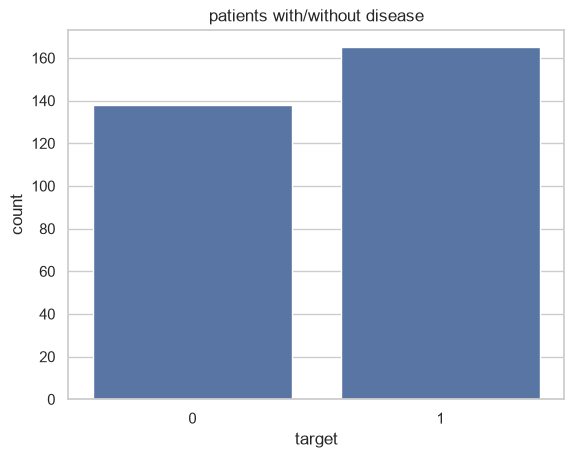

In [53]:
sns.countplot(x="target", data=df)
plt.title("patients with/without disease")
plt.show()


target      1.000000
cp          0.433798
thalach     0.421741
slope       0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
sex        -0.280937
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
Name: target, dtype: float64


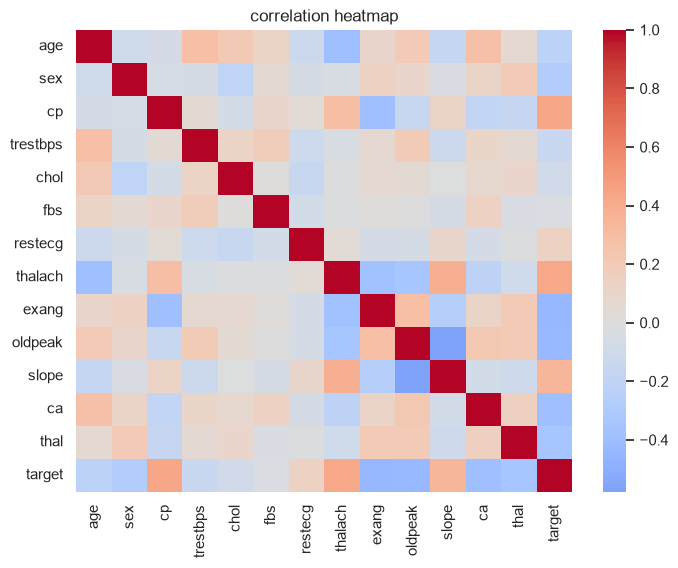

In [54]:
# which features move with target?
corr = df.corr()["target"].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("correlation heatmap")
plt.show()


### what the correlation is saying

looking at corr with target:
- positive: things like cp (chest pain type), thalach (max heart rate) tend to be higher when target=1 in this coding
- negative: exang (exercise angina), oldpeak (ST depression), ca (blocked vessels), thal often go opposite to "healthy"

so clinically that kind of tracks - exercise pain, ST changes, and more diseased vessels are bad signs.


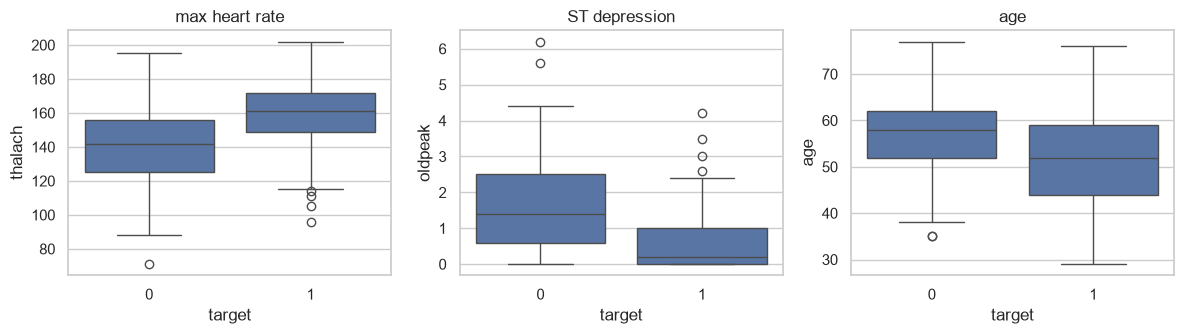

disease patients avg thalach: 158.5
no disease avg thalach: 139.1
disease avg oldpeak: 0.58
no disease avg oldpeak: 1.59


In [55]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
sns.boxplot(x="target", y="thalach", data=df, ax=axes[0])
axes[0].set_title("max heart rate")
sns.boxplot(x="target", y="oldpeak", data=df, ax=axes[1])
axes[1].set_title("ST depression")
sns.boxplot(x="target", y="age", data=df, ax=axes[2])
axes[2].set_title("age")
plt.tight_layout()
plt.show()

print("disease patients avg thalach:", round(df[df.target==1]["thalach"].mean(),1))
print("no disease avg thalach:", round(df[df.target==0]["thalach"].mean(),1))
print("disease avg oldpeak:", round(df[df.target==1]["oldpeak"].mean(),2))
print("no disease avg oldpeak:", round(df[df.target==0]["oldpeak"].mean(),2))


### boxplot notes

disease group has higher oldpeak (more ST depression on exercise) which doctors care about.
thalach also differs between groups in this dataset.
age overlap is big so age alone is not enough to separate patients.


## Preprocessing

cp, slope, thal etc are categories even though they are stored as numbers.
i one-hot encode those. then scale for models that need it.


In [56]:
cat_cols = ["cp", "restecg", "slope", "thal", "ca"]
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_enc.drop("target", axis=1)
y = df_enc["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(X_train.shape, X_test.shape)


(242, 22) (61, 22)


## Models

trying 4 classifiers and comparing them.
also doing 5-fold cross validation on train set.


In [57]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

# knn / lr use scaled data, trees can use either - i'll use scaled for all for simplicity
results = []

for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)

    # cv on train
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring="accuracy")

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append({
        "model": name,
        "cv_acc_mean": cv_scores.mean(),
        "test_acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    })

    print(name)
    print("  cv acc:", round(cv_scores.mean(), 3), "+/-", round(cv_scores.std(), 3))
    print("  test acc:", round(acc, 3), "recall:", round(rec, 3), "f1:", round(f1, 3))
    print()

results_df = pd.DataFrame(results).sort_values("recall", ascending=False)
results_df


Logistic Regression
  cv acc: 0.835 +/- 0.054
  test acc: 0.869 recall: 0.875 f1: 0.875

Decision Tree
  cv acc: 0.74 +/- 0.019
  test acc: 0.738 recall: 0.719 f1: 0.742

Random Forest
  cv acc: 0.806 +/- 0.037
  test acc: 0.852 recall: 0.812 f1: 0.852

KNN
  cv acc: 0.806 +/- 0.01
  test acc: 0.869 recall: 0.875 f1: 0.875



,model,cv_acc_mean,test_acc,precision,recall,f1
0,Logistic Regression,0.834609,0.868852,0.875000,0.87500,0.875000
3,KNN,0.805782,0.868852,0.875000,0.87500,0.875000
2,Random Forest,0.805527,0.852459,0.896552,0.81250,0.852459
1,Decision Tree,0.739796,0.737705,0.766667,0.71875,0.741935


## Confusion matrices


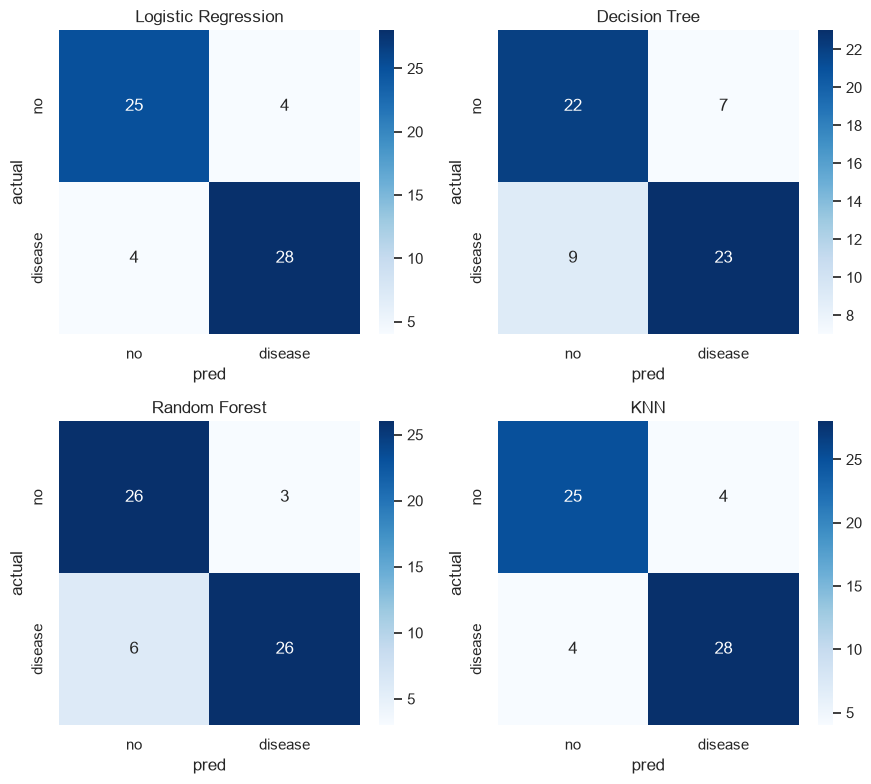

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    pred = model.predict(X_test_s)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["no", "disease"], yticklabels=["no", "disease"])
    axes[i].set_title(name)
    axes[i].set_xlabel("pred")
    axes[i].set_ylabel("actual")

plt.tight_layout()
plt.show()


## ROC curves


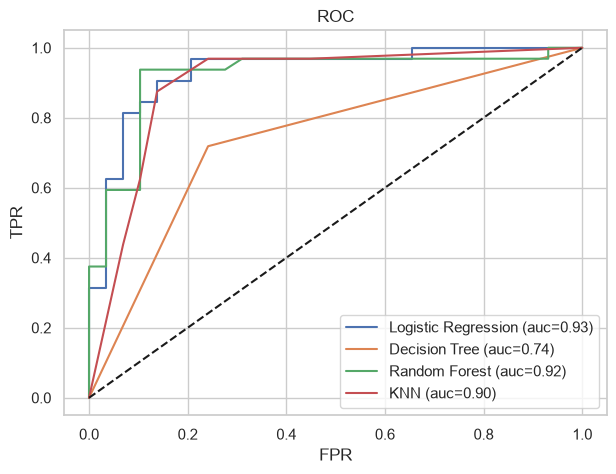

In [59]:
plt.figure(figsize=(7, 5))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_test_s)[:, 1]
    else:
        scores = model.decision_function(X_test_s)
    fpr, tpr, _ = roc_curve(y_test, scores)
    plt.plot(fpr, tpr, label=f"{name} (auc={auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC")
plt.legend()
plt.show()


## Feature importance (from Logistic Regression)

coefficients tell which inputs push the prediction toward disease.


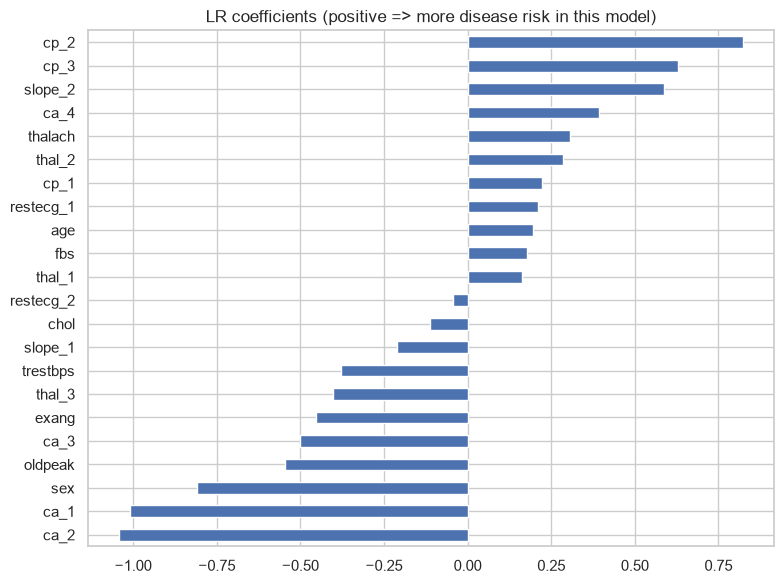

top positive (linked to disease):
thalach    0.306566
ca_4       0.393408
slope_2    0.586118
cp_3       0.627563
cp_2       0.822771
dtype: float64

top negative (linked to no disease / protective in model):
ca_2      -1.041499
ca_1      -1.009706
sex       -0.809595
oldpeak   -0.546936
ca_3      -0.500226
dtype: float64


In [60]:
lr = models["Logistic Regression"]
coefs = pd.Series(lr.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
coefs.plot(kind="barh")
plt.title("LR coefficients (positive => more disease risk in this model)")
plt.tight_layout()
plt.show()

print("top positive (linked to disease):")
print(coefs.tail(5))
print("\ntop negative (linked to no disease / protective in model):")
print(coefs.head(5))


## Summary / what this means clinically

I compared Logistic Regression, Decision Tree, Random Forest and KNN.
Look at the results table for exact scores - i sorted by recall because for heart disease missing a sick person is worse than an extra false alarm.

From EDA + LR coefficients, the useful risk signals in this data are things like:
- exercise induced angina / ST depression (oldpeak)
- number of vessels (ca)
- thalium test result
- chest pain type

max heart rate and some cp categories also show up depending on the model.

so if a doctor asked "what should i watch?", this notebook points more at exercise ECG related features and vessel / thalium results than just cholesterol alone (chol was not the strongest here).

limitations: only ~300 rows, one split + 5-fold cv on train, and the category codes are from a public dataset not a hospital EHR.
